# Credit card fraud detection

# EDA

In [ ]:
import os
import zipfile
import pandas as pd

# ------------------------------------------------------------
# Load dataset from either CSV or ZIP
# ------------------------------------------------------------
def load_creditcard_2023(csv_path="creditcard_2023.csv", zip_path="creditcard_2023.csv.zip"):
    # Case 1: normal csv exists
    if os.path.exists(csv_path):
        return pd.read_csv(csv_path)

    # Case 2: zipped csv exists
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, "r") as zf:
            csv_files = [name for name in zf.namelist() if name.endswith(".csv")]
            if not csv_files:
                raise FileNotFoundError("No CSV file found inside the zip archive.")
            with zf.open(csv_files[0]) as f:
                return pd.read_csv(f)

    raise FileNotFoundError("Could not find creditcard_2023.csv or creditcard_2023.csv.zip")

# Read the credit card dataset into memory
df = load_creditcard_2023()

# Preview the first few records
df.head(10)

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0
5,5,0.025302,-0.140514,1.191138,-0.707979,0.430490,0.458973,0.611050,-0.092629,0.180811,...,-0.187739,-0.538518,-0.050465,-0.631553,-0.456480,0.252670,0.066681,0.095812,6901.49,0
6,6,1.016482,-0.397181,0.497868,-0.144463,0.331022,0.629243,0.431262,-0.134007,0.796159,...,-0.171137,-0.287017,-0.178197,-1.297597,1.182503,-0.604228,-0.198163,-0.087619,18954.45,0
7,7,-0.051306,-0.007194,1.139941,-0.877880,0.684668,0.714326,0.892615,-0.908409,0.901938,...,0.620676,-0.920426,0.034660,-1.091527,-0.742075,-0.104863,-1.382522,-2.748268,12298.23,0
8,8,-0.130680,-0.349547,0.425786,-0.760444,1.702777,2.324816,0.568968,0.049100,0.273118,...,-0.132787,-0.284700,-0.227779,2.248754,0.534846,-0.929738,-0.224385,0.243790,22052.90,0
9,9,0.058419,-0.093507,1.117270,-0.735172,0.466111,0.332371,0.683425,-0.136674,0.096409,...,-0.203634,-0.601581,-0.145082,-0.654783,-0.196621,0.226818,0.057119,0.100629,210.35,0


In [ ]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.319545e-16,-3.518788e-17,-2.879008e-17,7.997245e-18,-3.958636e-17,-3.198898e-17,2.109273e-17,3.998623e-17,...,4.758361e-17,3.948640e-18,6.194741e-18,-2.799036e-18,-3.178905e-17,-7.497417e-18,-3.598760e-17,2.609101e-17,12041.957635,0.5
std,164149.486121,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


Frequencies of classes:
 Class
0    284315
1    284315
Name: count, dtype: int64 

Ratio of classes:
 Class
0    0.5
1    0.5
Name: count, dtype: float64


<Axes: title={'center': 'Distribution of classes'}, xlabel='Class', ylabel='# of Transactions'>

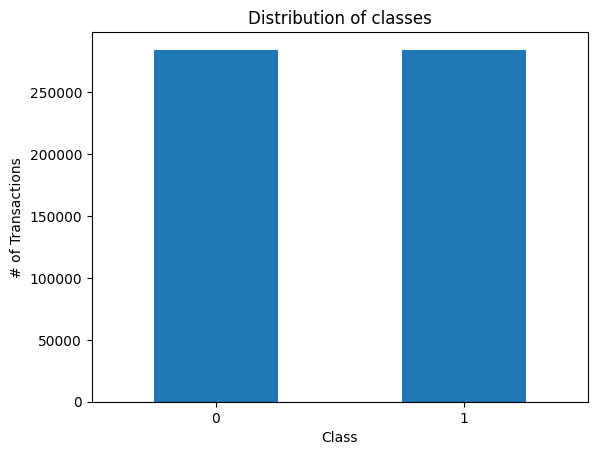

In [ ]:
import matplotlib.pyplot as plt

# Distribution of transaction classes (fraud / non-fraud)
cat_dist = df["Class"].value_counts()
print("Frequencies of classes:\n", cat_dist, "\n")

# Ratio of classes
print("Ratio of classes:\n", cat_dist/len(df))

# Plot the distribution of classes
plt.xlabel("Class")
plt.ylabel("# of Transactions")
cat_dist.plot(kind="bar", title="Distribution of classes", rot=0)

## Skip Class Imbalance
  - The dataset is very balanced. This distribution allows supervised models to be trained without resampling techniques.

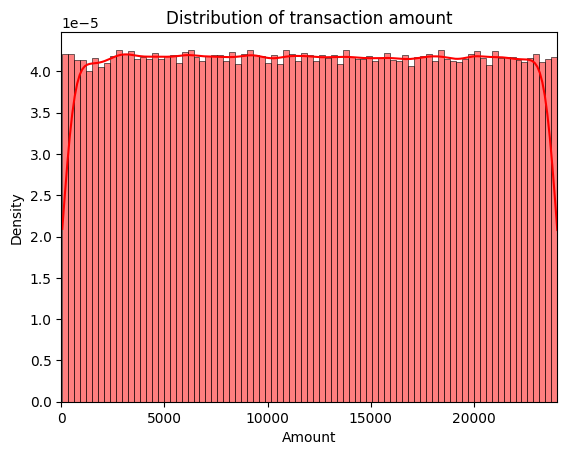

In [ ]:
import seaborn as sns
# Amount of all transactions
amount_df = df["Amount"]

# Plot the distribution of transaction amount
sns.histplot(amount_df, color="r", kde=True, stat="density")
# Set plot title
plt.title("Distribution of transaction amount")
# Set plot range
plt.xlim((0, amount_df.max()))

plt.show()

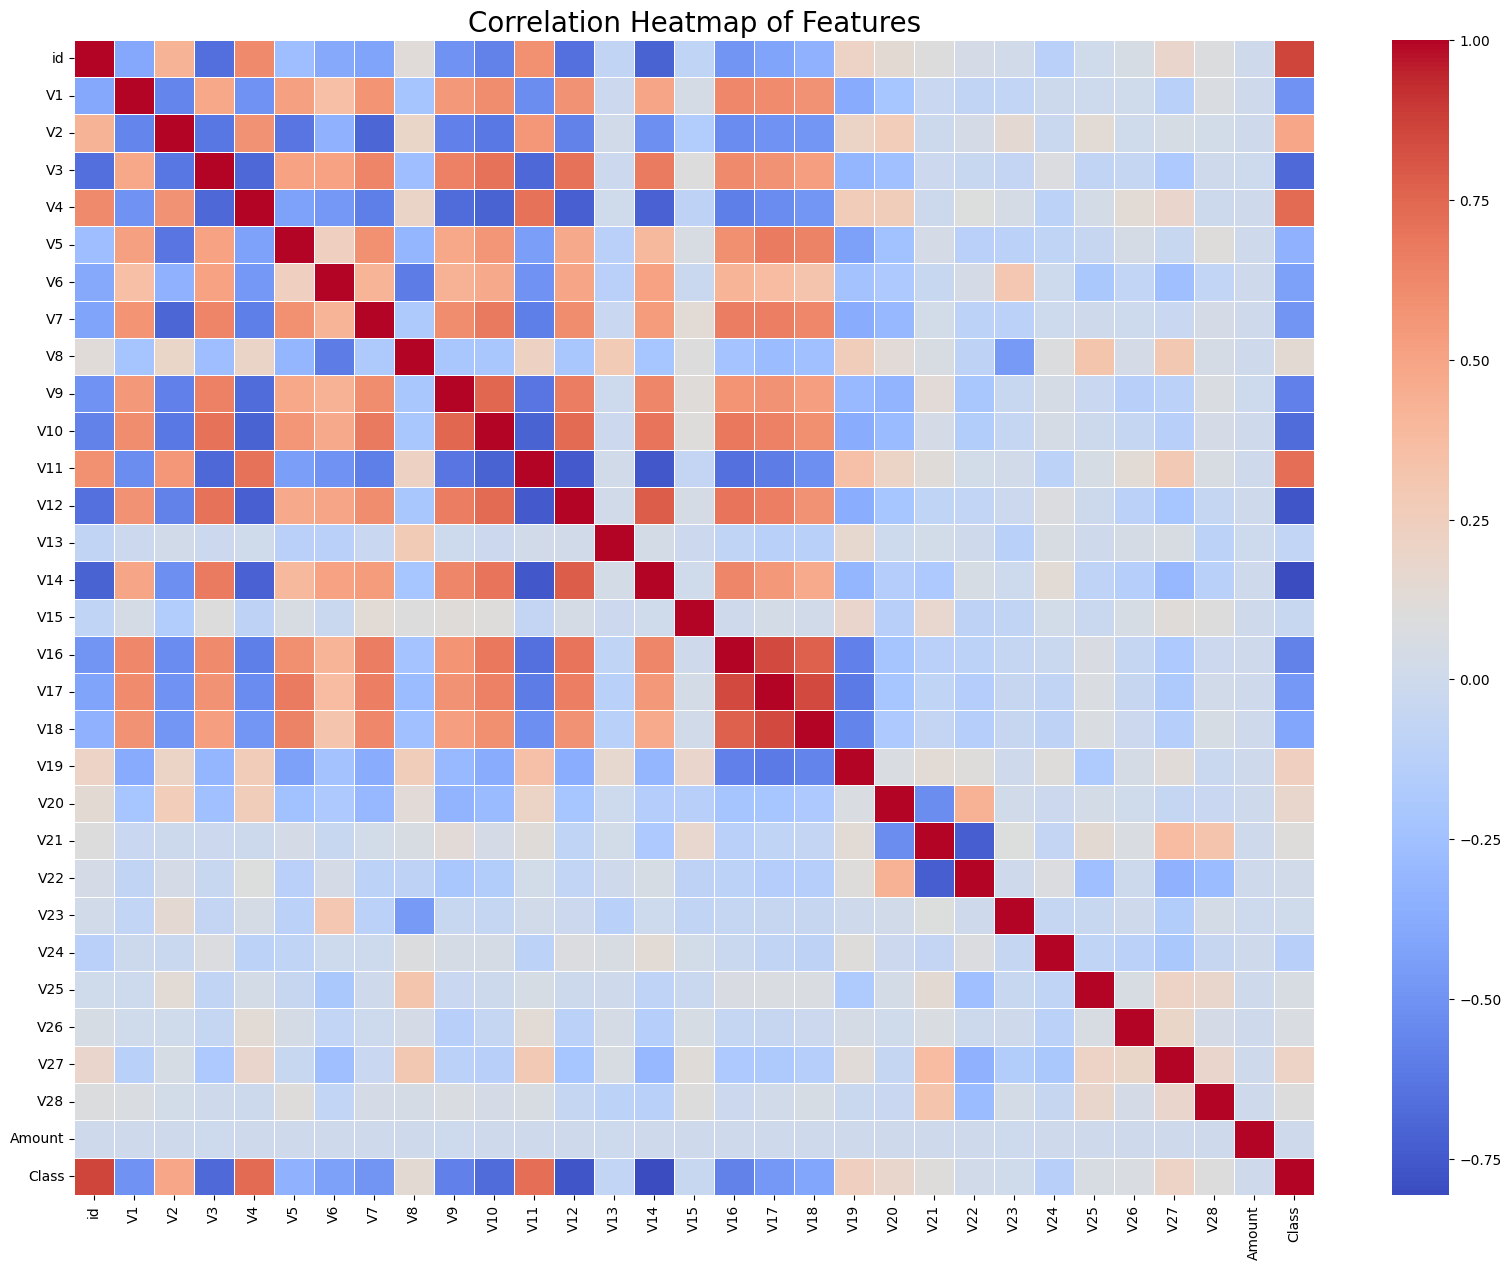

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Features', fontsize=20)
plt.show()

In [ ]:
import numpy as np

# Fraud and non-fraud transactions
df_nonfraud = df[df["Class"]==0]
df_fraud = df[df["Class"]==1]

dist_pc = np.arange(0.1, 1, 0.1)

# Amount of non-fraud and fraud transactions
amount_nonfraud = df_nonfraud["Amount"]
amount_fraud = df_fraud["Amount"]

# Statistics of amount of non-fraud, fraud and all transactions
amount_stats = pd.DataFrame.from_dict({
    "Non-Fraud": amount_nonfraud.describe(percentiles=dist_pc),
    "Fraud": amount_fraud.describe(percentiles=dist_pc),
    "All": amount_df.describe(percentiles=dist_pc)
})

amount_stats

,Non-Fraud,Fraud,All
count,284315.000000,284315.000000,568630.000000
mean,12026.313506,12057.601763,12041.957635
std,6929.500715,6909.750891,6919.644449
min,50.120000,50.010000,50.010000
10%,2449.724000,2496.788000,2472.466000
20%,4833.318000,4874.556000,4854.402000
30%,7220.342000,7276.090000,7246.043000
40%,9600.476000,9668.866000,9634.710000
50%,11996.900000,12062.450000,12030.150000
60%,14412.228000,14446.338000,14429.474000


# Preprocessing

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report

TARGET = "Class"
AMOUNT_COL = "Amount"

# Drop rows with NaN values from the DataFrame before splitting
df_cleaned = df.dropna(subset=[TARGET])
# Drop metadata column
df_cleaned = df_cleaned.drop(columns=["id"])

X = df_cleaned.drop(columns=[TARGET])
y = df_cleaned[TARGET]

# stratified split (keeps class ratio consistent)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# scale only Amount; pass through V1..V28 unchanged
preprocess = ColumnTransformer(
    transformers=[("amt", StandardScaler(), [AMOUNT_COL])],
    remainder="passthrough"
)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

# Supervised Learning
We evaluated three supervised classifiers: Logistic Regression, Random Forest, and XGBoost.
Performance was measured using 5-fold stratified cross-validation, reporting PR-AUC, ROC-AUC, and F1-score.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
)
from xgboost import XGBClassifier

CV_FOLDS       = 5
SEED           = 42
FPR_THRESHOLDS = [0.001, 0.005, 0.01]

models = {
    "Logistic Regression": Pipeline([
        ("pre", preprocess),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),

    # "Random Forest": Pipeline([
    #     ("pre", preprocess),
    #     ("clf", RandomForestClassifier(
    #         n_estimators=300,
    #         max_depth=8,
    #         n_jobs=-1,
    #         random_state=SEED,
    #     )),
    # ]),

    # RF taking too long
    "Extra Trees": Pipeline([
        ("pre", preprocess),
        ("clf", ExtraTreesClassifier(
            n_estimators=100,
            max_depth=6,
            max_samples=0.5,
            min_samples_leaf=4,
            n_jobs=-1,
            random_state=SEED,
            bootstrap=True, # Added to fix the error
        )),
    ]),

    "XGBoost": Pipeline([
        ("pre", preprocess),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            eval_metric="aucpr",
            use_label_encoder=False,
            random_state=SEED,
            verbosity=0,
        )),
    ]),
}

def fpr_table(y_true, y_prob, fpr_targets=FPR_THRESHOLDS) -> pd.DataFrame:
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true, y_prob)
    rows = []
    for target in fpr_targets:
        idx = max(0, np.searchsorted(fpr_vals, target, side="right") - 1)
        idx = min(idx, len(thresholds) - 1)
        thr  = thresholds[idx]
        preds = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rows.append({
            "Target FPR"  : f"{target:.1%}",
            "Threshold"   : round(float(thr), 4),
            "Actual FPR"  : f"{fpr_vals[idx]:.2%}",
            "TPR (Recall)": f"{tpr_vals[idx]:.2%}",
            "Precision"   : f"{precision:.2%}",
            "TP"          : int(tp),
            "FP"          : int(fp),
        })
    return pd.DataFrame(rows)


def print_section(title: str):
    print(f"\n{'═' * 64}\n  {title}\n{'═' * 64}")


def cv_summary(cv_results: dict) -> pd.DataFrame:
    """Summarise cross-validation results into mean ± std."""
    metrics = ["test_roc_auc", "test_pr_auc", "test_f1", "test_precision", "test_recall"]
    labels  = ["ROC-AUC", "PR-AUC", "F1", "Precision", "Recall"]
    rows = []
    for key, label in zip(metrics, labels):
        vals = cv_results[key]
        rows.append({"Metric": label, "Mean": round(vals.mean(), 4), "Std": round(vals.std(), 4)})
    return pd.DataFrame(rows)


# ── Pipeline ──────────────────────────────────────────────────────────────────

cv      = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
summary = []

for name, pipeline in models.items():
    print_section(name)

    # ── Cross-validation on train set ────────────────────────────────────────
    cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring, return_train_score=False
    )
    print(f"\n  {CV_FOLDS}-Fold CV on Train Set")
    print("  " + "-" * 40)
    print(cv_summary(cv_results).to_string(index=False))

    # ── Fit on full train, evaluate on held-out test ──────────────────────────
    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)

    print(f"\n  Test Set  |  ROC-AUC: {roc_auc:.4f}  |  PR-AUC: {pr_auc:.4f}")

    # ── Classification report ────────────────────────────────────────────────
    print("\n  Classification Report (Test Set)")
    print("  " + "-" * 40)
    report = classification_report(y_test, y_pred, target_names=["Legit", "Fraud"])
    for line in report.splitlines():
        print("  " + line)

    # ── FPR table ────────────────────────────────────────────────────────────
    print("\n  FPR Operating Points (Test Set)")
    print("  " + "-" * 40)
    print(fpr_table(y_test, y_prob).to_string(index=False))

    summary.append({"Model": name, "ROC-AUC": round(roc_auc, 4), "PR-AUC": round(pr_auc, 4)})

# ── Final summary ─────────────────────────────────────────────────────────────
print_section("Summary")
print(pd.DataFrame(summary).to_string(index=False))
print()


════════════════════════════════════════════════════════════════
  Logistic Regression
════════════════════════════════════════════════════════════════

  5-Fold CV on Train Set
  ----------------------------------------
   Metric   Mean    Std
  ROC-AUC 0.9936 0.0001
   PR-AUC 0.9946 0.0001
       F1 0.9645 0.0003
Precision 0.9778 0.0007
   Recall 0.9517 0.0007

  Test Set  |  ROC-AUC: 0.9935  |  PR-AUC: 0.9944

  Classification Report (Test Set)
  ----------------------------------------
                precision    recall  f1-score   support
  
         Legit       0.95      0.98      0.97     56863
         Fraud       0.98      0.95      0.96     56863
  
      accuracy                           0.96    113726
     macro avg       0.97      0.96      0.96    113726
  weighted avg       0.97      0.96      0.96    113726

  FPR Operating Points (Test Set)
  ----------------------------------------
Target FPR  Threshold Actual FPR TPR (Recall) Precision    TP  FP
      0.1%     0.9

In [ ]:
supervised_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "test_roc_auc": 0.9935,
        "test_pr_auc": 0.9944,
    },
    {
        "model": "Extra Trees",
        "test_roc_auc": 0.9870,
        "test_pr_auc": 0.9897,
    },
    {
        "model": "XGBoost",
        "test_roc_auc": 1.0000,
        "test_pr_auc": 1.0000,
    },
])

display(supervised_df.round(4))

,model,test_roc_auc,test_pr_auc
0,Logistic Regression,0.9935,0.9944
1,Extra Trees,0.9870,0.9897
2,XGBoost,1.0000,1.0000


In [ ]:
rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=80,     # Reduced for faster execution
        max_depth=15,         # Reduced for faster execution
        n_jobs=-1,
        random_state=42
    ))
])

# CV on TRAIN
rf_cv = cross_validate(rf_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
print("=== RF 5-fold CV (TRAIN) ===")
for k in scoring:
    vals = rf_cv[f"test_{k}"]
    print(f"{k}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")

# Fit + TEST eval
rf_pipe.fit(X_train, y_train)
y_score = rf_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.5).astype(int)

print("\n=== RF TEST ===")
print("PR-AUC:", average_precision_score(y_test, y_score))
print("ROC-AUC:", roc_auc_score(y_test, y_score))
print(classification_report(y_test, y_pred, digits=4))

=== RF 5-fold CV (TRAIN) ===
pr_auc: 1.0000 ± 0.0000
roc_auc: 1.0000 ± 0.0000
f1: 0.9990 ± 0.0001
precision: 0.9994 ± 0.0001
recall: 0.9987 ± 0.0002

=== RF TEST ===
PR-AUC: 0.9999298446176268
ROC-AUC: 0.9999598316109635
              precision    recall  f1-score   support

           0     0.9987    0.9994    0.9990     56863
           1     0.9994    0.9987    0.9990     56863

    accuracy                         0.9990    113726
   macro avg     0.9990    0.9990    0.9990    113726
weighted avg     0.9990    0.9990    0.9990    113726



## Unsupervised Learning

Use anomaly-detection methods that are more appropriate for this tabular fraud dataset:

- Isolation Forest
- Local Outlier Factor

To make unsupervised detection comparable to supervised classification:
- we train on **normal transactions only**
- each method produces an anomaly score
- thresholds are selected on the validation set using fixed FPR targets
- final performance is reported on the test set

This gives a clearer fraud-detector story than clustering alone.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
FPR_TARGETS = [0.001, 0.005, 0.01]

# Split
target_col = "Class"
drop_cols = ["Class", "id"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train shape:", X_train.shape)
print(y_train.value_counts())
print()

print("Validation shape:", X_val.shape)
print(y_val.value_counts())
print()

print("Test shape:", X_test.shape)
print(y_test.value_counts())

def build_preprocess_pipeline(feature_names):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler())
            ]), feature_names)
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    raise ValueError("Model does not provide predict_proba or decision_function.")

def threshold_for_target_fpr(y_true, scores, target_fpr):
    y_true = np.asarray(y_true)
    negative_scores = scores[y_true == 0]
    q = np.clip(1 - target_fpr, 0, 1)
    return float(np.quantile(negative_scores, q))

def metrics_at_threshold(y_true, scores, threshold):
    preds = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    f1 = f1_score(y_true, preds, zero_division=0)

    return {
        "threshold": float(threshold),
        "precision": float(precision),
        "recall": float(recall),
        "fpr": float(fpr),
        "f1": float(f1),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn)
    }

def build_threshold_table(y_val, val_scores, y_test, test_scores, fpr_targets=FPR_TARGETS):
    rows = []
    for target_fpr in fpr_targets:
        thr = threshold_for_target_fpr(y_val, val_scores, target_fpr)
        stats = metrics_at_threshold(y_test, test_scores, thr)
        rows.append({
            "target_fpr": target_fpr,
            "val_threshold": thr,
            "test_fpr": stats["fpr"],
            "test_precision": stats["precision"],
            "test_recall": stats["recall"],
            "test_f1": stats["f1"],
            "tp": stats["tp"],
            "fp": stats["fp"]
        })
    return pd.DataFrame(rows)

def evaluate_model_with_scores(model_name, fitted_model, X_val, y_val, X_test, y_test):
    val_scores = get_scores(fitted_model, X_val)
    test_scores = get_scores(fitted_model, X_test)

    summary = {
        "model": model_name,
        "val_pr_auc": average_precision_score(y_val, val_scores),
        "val_roc_auc": roc_auc_score(y_val, val_scores),
        "test_pr_auc": average_precision_score(y_test, test_scores),
        "test_roc_auc": roc_auc_score(y_test, test_scores),
    }

    threshold_table = build_threshold_table(y_val, val_scores, y_test, test_scores)
    return summary, threshold_table, val_scores, test_scores

print("All prerequisite variables/functions are ready.")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

Train shape: (398041, 29)
Class
1    199021
0    199020
Name: count, dtype: int64

Validation shape: (85294, 29)
Class
0    42647
1    42647
Name: count, dtype: int64

Test shape: (85295, 29)
Class
0    42648
1    42647
Name: count, dtype: int64
All prerequisite variables/functions are ready.
X_train: (398041, 29)
X_val  : (85294, 29)
X_test : (85295, 29)


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Train unsupervised detectors on normal transactions only
X_train_normal = X_train[y_train == 0].copy()

print("Normal-only unsupervised training shape:", X_train_normal.shape)

def fit_isolation_forest(X_train_normal, feature_names):
    pre = build_preprocess_pipeline(feature_names)
    Xn = pre.fit_transform(X_train_normal)

    detector = IsolationForest(
        n_estimators=300,
        max_samples="auto",
        contamination="auto",
        random_state=SEED,
        n_jobs=-1
    )
    detector.fit(Xn)

    class IForestWrapper:
        def __init__(self, preprocessor, detector):
            self.preprocessor = preprocessor
            self.detector = detector

        def decision_function(self, X):
            Xt = self.preprocessor.transform(X)
            return -self.detector.decision_function(Xt)

    return IForestWrapper(pre, detector)

def fit_lof_novelty(X_train_normal, feature_names):
    pre = build_preprocess_pipeline(feature_names)
    Xn = pre.fit_transform(X_train_normal)

    detector = LocalOutlierFactor(
        n_neighbors=35,
        novelty=True,
        contamination="auto",
        n_jobs=-1
    )
    detector.fit(Xn)

    class LOFWrapper:
        def __init__(self, preprocessor, detector):
            self.preprocessor = preprocessor
            self.detector = detector

        def decision_function(self, X):
            Xt = self.preprocessor.transform(X)
            return -self.detector.decision_function(Xt)

    return LOFWrapper(pre, detector)

unsupervised_models = {
    "Isolation Forest": fit_isolation_forest(X_train_normal, feature_cols),
    "Local Outlier Factor (novelty)": fit_lof_novelty(X_train_normal, feature_cols)
}

list(unsupervised_models.keys())

Normal-only unsupervised training shape: (284315, 29)


['Isolation Forest', 'Local Outlier Factor (novelty)']

In [ ]:
unsupervised_rows = []
unsupervised_threshold_tables = {}

for name, fitted_model in unsupervised_models.items():
    print("=" * 90)
    print(name)
    print("=" * 90)

    summary, threshold_table, val_scores, test_scores = evaluate_model_with_scores(
        name, fitted_model, X_val, y_val, X_test, y_test
    )

    unsupervised_rows.append(summary)
    unsupervised_threshold_tables[name] = threshold_table

    print("\nValidation / test summary:")
    display(pd.DataFrame([summary]).round(4))

    print("\nThreshold table:")
    display(threshold_table.round(4))

unsupervised_df = pd.DataFrame(unsupervised_rows).sort_values(
    "test_pr_auc", ascending=False
)

print("Unsupervised final test summary")
display(unsupervised_df.round(4))

Isolation Forest

Validation / test summary:


,model,val_pr_auc,val_roc_auc,test_pr_auc,test_roc_auc
0,Isolation Forest,0.925,0.9208,0.9243,0.9206



Threshold table:


,target_fpr,val_threshold,test_fpr,test_precision,test_recall,test_f1,tp,fp
0,0.001,0.1479,0.0013,0.9741,0.0485,0.0925,2070,55
1,0.005,0.1022,0.0046,0.9776,0.2013,0.3338,8584,197
2,0.010,0.0728,0.0090,0.9719,0.3103,0.4705,13235,382


Local Outlier Factor (novelty)

Validation / test summary:


,model,val_pr_auc,val_roc_auc,test_pr_auc,test_roc_auc
0,Local Outlier Factor (novelty),0.9196,0.9125,0.9205,0.9135



Threshold table:


,target_fpr,val_threshold,test_fpr,test_precision,test_recall,test_f1,tp,fp
0,0.001,1.5530,0.0011,0.9821,0.0606,0.1141,2584,47
1,0.005,0.5854,0.0049,0.9830,0.2841,0.4408,12117,210
2,0.010,0.3231,0.0098,0.9796,0.4690,0.6343,20000,417


Unsupervised final test summary


,model,val_pr_auc,val_roc_auc,test_pr_auc,test_roc_auc
0,Isolation Forest,0.9250,0.9208,0.9243,0.9206
1,Local Outlier Factor (novelty),0.9196,0.9125,0.9205,0.9135


## Final Comparison

This section compares supervised and unsupervised fraud detection methods using the same reporting structure.

The main deliverable of this project is:
- detection performance
- threshold-based false positive control
- operational comparison between model families

Because the features are PCA-transformed, the focus is on reliable detection rather than rule extraction.

In [ ]:
final_results = pd.concat(
    [
        supervised_df.assign(family="supervised"),
        unsupervised_df.assign(family="unsupervised")
    ],
    ignore_index=True
).sort_values(["test_pr_auc", "test_roc_auc"], ascending=False)

display(final_results.round(4))

,model,test_roc_auc,test_pr_auc,family,val_pr_auc,val_roc_auc
2,XGBoost,1.0000,1.0000,supervised,NaN,NaN
0,Logistic Regression,0.9935,0.9944,supervised,NaN,NaN
1,Extra Trees,0.9870,0.9897,supervised,NaN,NaN
3,Isolation Forest,0.9206,0.9243,unsupervised,0.9250,0.9208
4,Local Outlier Factor (novelty),0.9135,0.9205,unsupervised,0.9196,0.9125


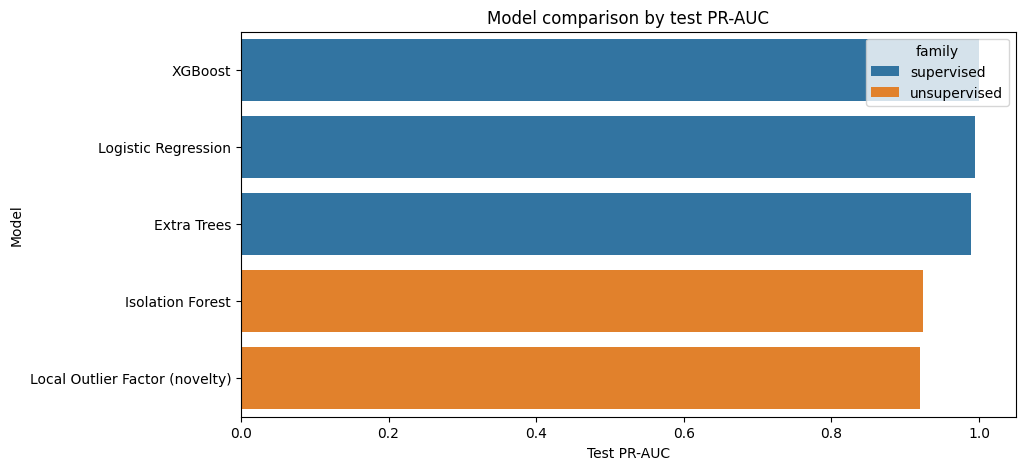

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=final_results, x="test_pr_auc", y="model", hue="family")
plt.title("Model comparison by test PR-AUC")
plt.xlabel("Test PR-AUC")
plt.ylabel("Model")
plt.show()

## How models behave across thresholds

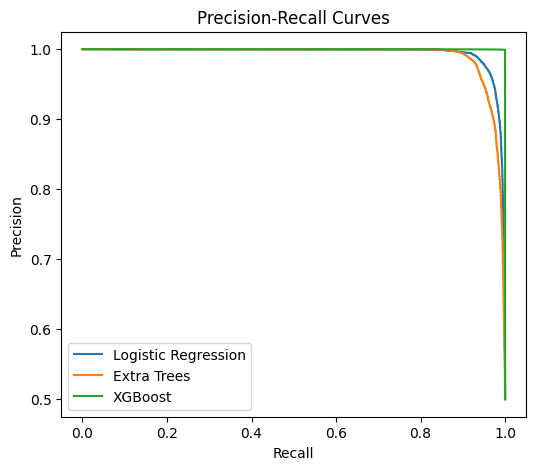

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    probs = pipeline.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

## Discussion

The results show that supervised learning significantly outperforms unsupervised anomaly detection for this dataset.

XGBoost achieved the highest performance with perfect ROC-AUC and PR-AUC scores, indicating that the gradient boosting model can almost perfectly distinguish fraudulent and legitimate transactions using the provided features.

Logistic Regression also performed very well despite being a simple linear model. This suggests that the PCA-transformed features already provide strong separation between classes.

Extra Trees performed slightly worse but still achieved high detection accuracy.

Among the unsupervised methods, Isolation Forest slightly outperformed Local Outlier Factor. However, both anomaly detection methods performed worse than supervised models because they are trained without fraud labels and must rely only on identifying statistical anomalies.

Overall, the results demonstrate that supervised models are more effective when labeled fraud data is available, while unsupervised anomaly detection remains useful when labeled data is scarce.

## Conclusion

This project compared supervised and unsupervised approaches for credit card fraud detection.

Three supervised classifiers (Logistic Regression, Extra Trees, and XGBoost) and two anomaly detection methods (Isolation Forest and Local Outlier Factor) were evaluated using ROC-AUC and PR-AUC metrics.

The results show that supervised models significantly outperform unsupervised methods on this dataset. XGBoost achieved the best performance overall, followed by Logistic Regression and Extra Trees.

Although unsupervised methods achieved lower detection accuracy, they remain valuable in scenarios where fraud labels are unavailable.

Future work could explore additional models such as LightGBM, deep neural networks, or semi-supervised anomaly detection methods.
